In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_returns_synthetic_data.csv to ecommerce_returns_synthetic_data.csv


In [ ]:
import pandas as pd

df = pd.read_csv('ecommerce_returns_synthetic_data.csv')

df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,NaN,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,NaN,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,NaN,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37


In [ ]:

df = df.drop_duplicates()

df = df.fillna(method='ffill')

df.columns = df.columns.str.strip().str.replace(" ", "_")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Product_ID        10000 non-null  object 
 2   User_ID           10000 non-null  object 
 3   Order_Date        10000 non-null  object 
 4   Return_Date       10000 non-null  object 
 5   Product_Category  10000 non-null  object 
 6   Product_Price     10000 non-null  float64
 7   Order_Quantity    10000 non-null  int64  
 8   Return_Reason     10000 non-null  object 
 9   Return_Status     10000 non-null  object 
 10  Days_to_Return    10000 non-null  float64
 11  User_Age          10000 non-null  int64  
 12  User_Gender       10000 non-null  object 
 13  User_Location     10000 non-null  object 
 14  Payment_Method    10000 non-null  object 
 15  Shipping_Method   10000 non-null  object 
 16  Discount_Applied  10000 non-null  float64

/tmp/ipykernel_367/723805012.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
print(df.columns)

Index(['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Return_Date',
       'Product_Category', 'Product_Price', 'Order_Quantity', 'Return_Reason',
       'Return_Status', 'Days_to_Return', 'User_Age', 'User_Gender',
       'User_Location', 'Payment_Method', 'Shipping_Method',
       'Discount_Applied'],
      dtype='object')


In [ ]:
df['Return_Status'].unique()

array(['Returned', 'Not Returned'], dtype=object)

In [ ]:
df['Return_Status'] = df['Return_Status'].map({
    'Returned': 1,
    'Not Returned': 0
})

In [ ]:
df['Return_Status'].head()

,Return_Status
0,1
1,1
2,0
3,0
4,0


In [ ]:
df['Return_Status'].mean() * 100

np.float64(50.519999999999996)

In [ ]:
df.groupby('Product_Category')['Return_Status'].mean().sort_values(ascending=False)

,Return_Status
Product_Category,
Clothing,0.524500
Electronics,0.509320
Books,0.506614
Toys,0.495370
Home,0.490148


In [ ]:
df.groupby('User_Location')['Return_Status'].mean()

,Return_Status
User_Location,
City1,0.429825
City10,0.598039
City100,0.481132
City11,0.494949
City12,0.540816
...,...
City95,0.554217
City96,0.483871
City97,0.500000


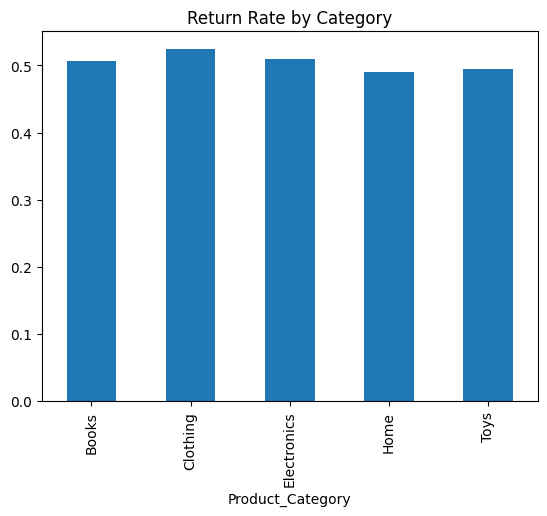

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Product_Category')['Return_Status'].mean().plot(kind='bar')
plt.title("Return Rate by Category")
plt.show()

In [ ]:
product_risk = df.groupby('Product_ID')['Return_Status'].mean().reset_index()

high_risk = product_risk[product_risk['Return_Status'] > 0.5]

high_risk.to_csv("high_risk_products.csv", index=False)

high_risk.head()

,Product_ID,Return_Status
0,PROD00000000,1.0
1,PROD00000001,1.0
5,PROD00000005,1.0
6,PROD00000006,1.0
7,PROD00000007,1.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Return_Status', axis=1)
y = df['Return_Status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4915
              precision    recall  f1-score   support

           0       0.50      0.40      0.44      1009
           1       0.49      0.59      0.53       991

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



In [ ]:
df['Return_Probability'] = model.predict_proba(X)[:,1]

In [ ]:
def risk_level(x):
    if x < 0.3:
        return "Low"
    elif x < 0.6:
        return "Medium"
    else:
        return "High"

df['Risk_Level'] = df['Return_Probability'].apply(risk_level)

In [ ]:
df.to_csv("final_with_risk_scores.csv", index=False)

In [ ]:
files.download("final_with_risk_scores.csv")
files.download("high_risk_products.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>